<a href="https://colab.research.google.com/github/NatGN/Practicas-de-seminario-de-mineria-de-datos/blob/main/Cluster_Codo2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#EJERCICIO 2: AGRUPAMIENTO DE PERSONAS SEGÚN SALUD FÍSICA (K-MEANS)

In [1]:
# 0. Importar las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [2]:
#Crear el dataframe
datos_salud = {
    'Ejercicio_Semanal': [0.5, 1, 1.5, 6, 7, 8, 2, 3, 4],
    'Condicion_Fisica': [2, 3, 2.5, 8, 9, 10, 4, 5, 6]
}
df_salud = pd.DataFrame(datos_salud)
X_salud = df_salud[['Ejercicio_Semanal', 'Condicion_Fisica']]

print("--- DataFrame de Salud Física ---")
print(df_salud)
print("\n" + "="*50 + "\n")


--- DataFrame de Salud Física ---
   Ejercicio_Semanal  Condicion_Fisica
0                0.5               2.0
1                1.0               3.0
2                1.5               2.5
3                6.0               8.0
4                7.0               9.0
5                8.0              10.0
6                2.0               4.0
7                3.0               5.0
8                4.0               6.0




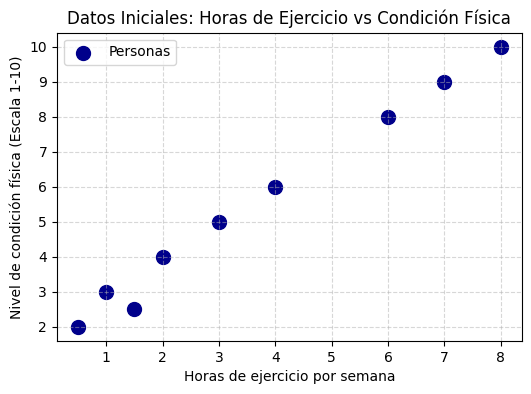

In [3]:
#Visualizacion de los datos
plt.figure(figsize=(6, 4))
plt.scatter(df_salud['Ejercicio_Semanal'], df_salud['Condicion_Fisica'], color='darkblue', s=100, label='Personas')
plt.title('Datos Iniciales: Horas de Ejercicio vs Condición Física')
plt.xlabel('Horas de ejercicio por semana')
plt.ylabel('Nivel de condición física (Escala 1-10)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

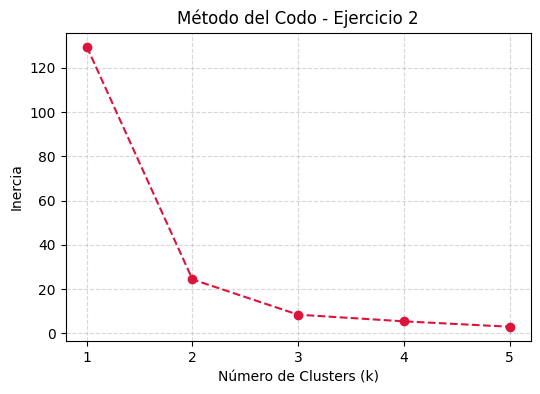

In [4]:
# 3. Aplicar K-Means con k = (Método del codo)
inercias_salud = []
rango_k = range(1, 6)

for k in rango_k:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_test.fit(X_salud)
    inercias_salud.append(kmeans_test.inertia_)

# Graficar el método del codo
plt.figure(figsize=(6, 4))
plt.plot(rango_k, inercias_salud, marker='o', color='crimson', linestyle='--')
plt.title('Método del Codo - Ejercicio 2')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.xticks(rango_k)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Al revisar la curva, el punto de inflexión ("codo") se sitúa de forma óptima en k = 3.
k_optimo = 3

In [5]:
# 4. Identificar clusters (Asignación)
kmeans_salud = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
df_salud['Cluster'] = kmeans_salud.fit_predict(X_salud)

print("--- Datos con Cluster Asignado ---")
print(df_salud)
print("\n" + "="*50 + "\n")


--- Datos con Cluster Asignado ---
   Ejercicio_Semanal  Condicion_Fisica  Cluster
0                0.5               2.0        0
1                1.0               3.0        0
2                1.5               2.5        0
3                6.0               8.0        1
4                7.0               9.0        1
5                8.0              10.0        1
6                2.0               4.0        0
7                3.0               5.0        2
8                4.0               6.0        2




In [6]:
# 5. Obtener los centroides
centroides_salud = kmeans_salud.cluster_centers_
print("--- Coordenadas de los Centroides ---")
for i, centroide in enumerate(centroides_salud):
    print(f"Cluster {i}: Horas Ejercicio Promedio = {centroide[0]:.2f} hrs, Condición Física Promedio = {centroide[1]:.2f}/10")
print("\n" + "="*50 + "\n")


--- Coordenadas de los Centroides ---
Cluster 0: Horas Ejercicio Promedio = 1.25 hrs, Condición Física Promedio = 2.88/10
Cluster 1: Horas Ejercicio Promedio = 7.00 hrs, Condición Física Promedio = 9.00/10
Cluster 2: Horas Ejercicio Promedio = 3.50 hrs, Condición Física Promedio = 5.50/10




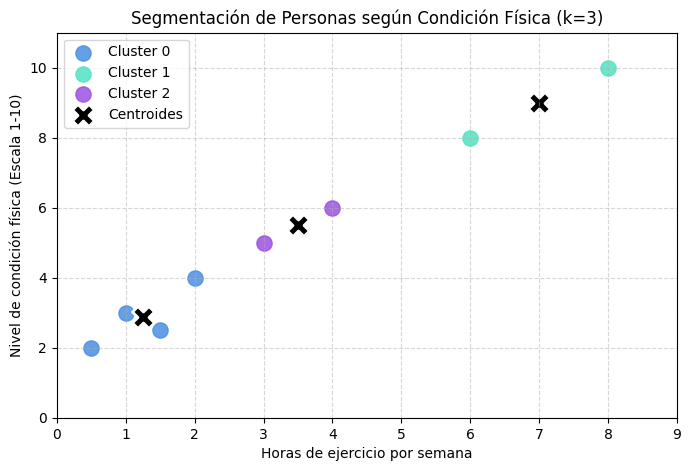

In [7]:

# 6. Graficar los resultados
plt.figure(figsize=(8, 5))
colores = ['#4A90E2', '#50E3C2', '#9B51E0'] # Paleta visualmente clara

for i in range(k_optimo):
    cluster_mask = df_salud['Cluster'] == i
    plt.scatter(df_salud.loc[cluster_mask, 'Ejercicio_Semanal'],
                df_salud.loc[cluster_mask, 'Condicion_Fisica'],
                color=colores[i], s=120, label=f'Cluster {i}', alpha=0.85)

# Dibujar centroides en el mapa
plt.scatter(centroides_salud[:, 0], centroides_salud[:, 1],
            color='black', marker='X', s=250, label='Centroides', edgecolor='white', linewidth=2)

plt.title('Segmentación de Personas según Condición Física (k=3)')
plt.xlabel('Horas de ejercicio por semana')
plt.ylabel('Nivel de condición física (Escala 1-10)')
plt.xlim(0, 9)
plt.ylim(0, 11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

¿Cómo describirías cada grupo de personas?

Grupo Sedentario / Condición Baja (Aprox. Horas: 1.0, Condición: ~2.5): Este segmento representa a personas con hábitos muy sedentarios. Dedican apenas entre 30 minutos y una hora y media a ejercitarse por semana, lo que se refleja de forma directa en un nivel de condición física notablemente bajo (puntuaciones de 2 a 3).

Grupo Moderado / Condición Intermedia (Aprox. Horas: 3.0, Condición: ~5.0): Son personas activas de manera recreativa o intermitente. Entrenan entre 2 y 4 horas semanales, logrando mantener un estado de salud y resistencia física en un nivel intermedio o promedio (puntuaciones de 4 a 6).

Grupo Entusiasta del Fitness / Condición Excelente (Aprox. Horas: 7.0, Condición: ~9.0): Este sector demuestra una alta disciplina. Registran una inversión de tiempo significativa en el deporte (entre 6 y 8 horas semanales), obteniendo como resultado un estado físico sobresaliente o de alto rendimiento (puntuaciones de 8 a 10).